<a href="https://colab.research.google.com/github/gongyu-wang/IDX-Exchange-project-work/blob/main/05_advanced_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/gongyu-wang/IDX-Exchange-project-work/blob/main/05_advanced_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Advanced Models

**Objective:** determine whether time-aware XGBoost tuning improves on the Week 6 Random Forest benchmark when both models use the same updated feature set and June 2026 test period.

Hyperparameters are tuned only inside the training period. Validation chooses between model families. The test month is evaluated once after selection.


## Fixed evaluation window

| Split | Period |
|---|---|
| Train | May 2025-April 2026 |
| Validation | May 2026 |
| Test | June 2026 |

Keeping these periods fixed makes the old-vs-new feature comparison interpretable.


In [1]:
from pathlib import Path
import os

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    from google.colab import drive
    drive.mount('/content/drive')
except (ImportError, ModuleNotFoundError):
    pass

sns.set_theme(style='whitegrid')


Mounted at /content/drive


## 1. Load the fixed June-test split


In [2]:
OUTPUT_DIR = Path(os.getenv('IDX_OUTPUT_DIR', '/content/drive/MyDrive/IDX Exchange/outputs'))
DISTRICT_PATH = Path(os.getenv('IDX_DISTRICT_PATH', '/content/drive/MyDrive/IDX Exchange/DistrictAreas.geojson'))
FEATURE_DIR = OUTPUT_DIR / 'feature_engineering'
FEATURE_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    'train': OUTPUT_DIR / 'crmls_sfr_train_X12_2025-05_to_2026-04.csv',
    'validation': OUTPUT_DIR / 'crmls_sfr_validation_2026-05.csv',
    'test': OUTPUT_DIR / 'crmls_sfr_test_2026-06.csv',
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError('Run Notebook 02 with June data first. Missing: ' + ', '.join(missing))

frames = {name: pd.read_csv(path, low_memory=False) for name, path in paths.items()}
for name, frame in frames.items():
    print(name, frame.shape, paths[name].name)


train (118774, 155) crmls_sfr_train_X12_2025-05_to_2026-04.csv
validation (11984, 155) crmls_sfr_validation_2026-05.csv
test (12827, 155) crmls_sfr_test_2026-06.csv


## 2. Define old and new features

The old feature set represents information available before Week 6. The new set adds ratios, property age, amenity density, seasonal context, and an independently sourced school-district layer.


In [3]:
TARGET = 'ClosePrice'
OLD_NUMERIC_CANDIDATES = [
    'LivingArea', 'BedroomsTotal', 'BathroomsTotalInteger', 'LotSizeSquareFeet',
    'LotSizeAcres', 'LotSizeArea', 'YearBuilt', 'GarageSpaces', 'ParkingTotal',
    'Latitude', 'Longitude', 'AssociationFee', 'Stories', 'MainLevelBedrooms',
    'FireplacesTotal',
]
OLD_CATEGORICAL_CANDIDATES = [
    'City', 'PostalCode', 'CountyOrParish', 'MLSAreaMajor',
    'HighSchoolDistrict', 'ElementarySchoolDistrict',
    'MiddleOrJuniorSchoolDistrict', 'Levels',
    'AssociationFeeFrequency', 'StateOrProvince',
]
AMENITY_COLUMNS = [
    'ViewYN', 'WaterfrontYN', 'BasementYN', 'PoolPrivateYN',
    'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN',
]
NEW_NUMERIC = [
    'BedBathRatio', 'PropertyAge', 'LivingAreaToLotRatio',
    'AmenitiesCount', 'CloseMonthSin', 'CloseMonthCos',
]
NEW_CATEGORICAL = ['DistrictName']

OLD_NUMERIC = [c for c in OLD_NUMERIC_CANDIDATES if all(c in f.columns for f in frames.values())]
OLD_CATEGORICAL = [c for c in OLD_CATEGORICAL_CANDIDATES if all(c in f.columns for f in frames.values())]
required = set(AMENITY_COLUMNS + [TARGET, 'CloseDate', 'Latitude', 'Longitude'])
for name, frame in frames.items():
    missing_columns = sorted(required - set(frame.columns))
    if missing_columns:
        raise KeyError(f'{name} is missing required fields: {missing_columns}')
print(f'Leakage-safe base pool: {len(OLD_NUMERIC)} numeric + {len(OLD_CATEGORICAL)} categorical + {len(AMENITY_COLUMNS)} binary fields')


Leakage-safe base pool: 15 numeric + 10 categorical + 7 binary fields


## 3. Engineer property-level features


In [4]:
TRUE_VALUES = {'true', 't', 'yes', 'y', '1'}

def add_property_features(frame):
    result = frame.copy()
    close_date = pd.to_datetime(result['CloseDate'], errors='coerce')
    bedrooms = pd.to_numeric(result['BedroomsTotal'], errors='coerce')
    bathrooms = pd.to_numeric(result['BathroomsTotalInteger'], errors='coerce')
    living_area = pd.to_numeric(result['LivingArea'], errors='coerce')
    lot_size = pd.to_numeric(result['LotSizeSquareFeet'], errors='coerce')
    year_built = pd.to_numeric(result['YearBuilt'], errors='coerce')

    result['BedBathRatio'] = bedrooms / bathrooms.where(bathrooms > 0)
    result['PropertyAge'] = (close_date.dt.year - year_built).clip(lower=0, upper=250)
    result['LivingAreaToLotRatio'] = living_area / lot_size.where(lot_size > 0)
    result['CloseMonthSin'] = np.sin(2 * np.pi * close_date.dt.month / 12)
    result['CloseMonthCos'] = np.cos(2 * np.pi * close_date.dt.month / 12)

    amenity_values = pd.DataFrame(index=result.index)
    for column in AMENITY_COLUMNS:
        amenity_values[column] = (
            result[column].astype(str).str.strip().str.lower().isin(TRUE_VALUES).astype(int)
        )
        result[column] = amenity_values[column]
    result['AmenitiesCount'] = amenity_values.sum(axis=1)
    return result

engineered = {name: add_property_features(frame) for name, frame in frames.items()}
engineered['train'][NEW_NUMERIC].describe().T


,count,mean,std,min,25%,50%,75%,max
BedBathRatio,118736.0,1.458686,0.473016,0.00000,1.000000,1.500000e+00,1.500000,7.500000
PropertyAge,118774.0,49.868751,27.433623,0.00000,28.000000,5.000000e+01,70.000000,225.000000
LivingAreaToLotRatio,118774.0,20.957632,595.966240,0.00016,0.167639,2.364113e-01,0.333391,60566.666667
AmenitiesCount,118774.0,2.232383,1.021722,0.00000,2.000000,2.000000e+00,3.000000,6.000000
CloseMonthSin,118774.0,-0.064696,0.723986,-1.00000,-0.866025,-2.449294e-16,0.500000,1.000000
CloseMonthCos,118774.0,-0.113508,0.677335,-1.00000,-0.866025,-1.836970e-16,0.500000,1.000000


## 4. Spatially join California school districts


In [5]:
if not DISTRICT_PATH.exists():
    raise FileNotFoundError(f'School-district boundary file not found: {DISTRICT_PATH}')

districts = gpd.read_file(DISTRICT_PATH)
if districts.crs is None:
    raise ValueError('The school-district boundary file has no CRS metadata.')

name_candidates = [
    'DistrictName', 'DISTRICT', 'NAME', 'Name', 'district',
    'LEA_NAME', 'UNIFIED', 'SchoolDistrict',
]
district_name_column = next((column for column in name_candidates if column in districts.columns), None)
if district_name_column is None:
    text_columns = [column for column in districts.columns if column != 'geometry' and districts[column].dtype == 'object']
    if not text_columns:
        raise KeyError('Could not identify a district-name column in the boundary file.')
    district_name_column = text_columns[0]

district_lookup = districts[[district_name_column, 'geometry']].rename(columns={district_name_column: 'DistrictName'})

def add_school_district(frame):
    valid_coordinates = frame['Latitude'].notna() & frame['Longitude'].notna()
    result = frame.copy()
    result['DistrictName'] = 'Unknown District'
    points = gpd.GeoDataFrame(
        result.loc[valid_coordinates, ['Latitude', 'Longitude']].copy(),
        geometry=gpd.points_from_xy(
            result.loc[valid_coordinates, 'Longitude'],
            result.loc[valid_coordinates, 'Latitude'],
        ),
        crs='EPSG:4326',
    ).to_crs(district_lookup.crs)
    joined = gpd.sjoin(points, district_lookup, how='left', predicate='within')
    district_values = joined.groupby(level=0)['DistrictName'].first().fillna('Unknown District')
    result.loc[district_values.index, 'DistrictName'] = district_values
    return result

engineered = {name: add_school_district(frame) for name, frame in engineered.items()}

coverage = pd.DataFrame([
    {
        'Split': name,
        'Rows': len(frame),
        'MatchedDistrictRows': int(frame['DistrictName'].ne('Unknown District').sum()),
        'MatchRate_pct': frame['DistrictName'].ne('Unknown District').mean() * 100,
        'UniqueDistricts': frame.loc[frame['DistrictName'].ne('Unknown District'), 'DistrictName'].nunique(),
    }
    for name, frame in engineered.items()
])
display(coverage.style.format({'MatchRate_pct': '{:.2f}%'}))

# Define the primary market population from training data only.
# Full validation/test frames are preserved for robustness reporting.
full_engineered = {name: frame.copy() for name, frame in engineered.items()}
train_reference = full_engineered['train']
price_low, price_high = train_reference[TARGET].quantile([0.005, 0.995])
train_ppsf = train_reference[TARGET] / pd.to_numeric(train_reference['LivingArea'], errors='coerce').where(lambda s: s > 0)
price_ok = train_reference[TARGET].between(price_low, price_high)
ppsf_low, ppsf_high = train_ppsf[price_ok].dropna().quantile([0.005, 0.995])

def primary_population_mask(frame):
    living_area = pd.to_numeric(frame['LivingArea'], errors='coerce')
    ppsf = frame[TARGET] / living_area.where(living_area > 0)
    return frame[TARGET].between(price_low, price_high) & (ppsf.isna() | ppsf.between(ppsf_low, ppsf_high))

engineered = {name: frame.loc[primary_population_mask(frame)].copy() for name, frame in full_engineered.items()}
population_summary = pd.DataFrame([
    {'Split': name.title(), 'FullRows': len(full_engineered[name]), 'PrimaryInRangeRows': len(engineered[name])}
    for name in ['train', 'validation', 'test']
])
display(population_summary)
print(f'Train-defined ClosePrice range: ${price_low:,.0f} to ${price_high:,.0f}')
print(f'Train-defined price/sqft range: ${ppsf_low:,.0f} to ${ppsf_high:,.0f}')


,Split,Rows,MatchedDistrictRows,MatchRate_pct,UniqueDistricts
0,train,118774,118760,99.99%,594
1,validation,11984,11984,100.00%,455
2,test,12827,12827,100.00%,447


,Split,FullRows,PrimaryInRangeRows
0,Train,118774,116424
1,Validation,11984,11735
2,Test,12827,12543


Train-defined ClosePrice range: $190,000 to $8,750,000
Train-defined price/sqft range: $164 to $2,127


## 5. Modeling protocol

- Updated Week 6 property and school-district features are used by both models.
- Random Forest configuration is carried forward unchanged as the benchmark.
- XGBoost hyperparameters are searched with `TimeSeriesSplit`, never random K-fold.
- The search optimizes MdAPE because it represents the typical percentage prediction error.
- June test performance is not used for tuning or model selection.


In [6]:
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

try:
    from xgboost import XGBRegressor
except (ImportError, OSError) as error:
    raise ImportError(
        'XGBoost could not be loaded. In Google Colab run `%pip install -q xgboost` and restart the runtime.'
    ) from error

def regression_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    ape = np.abs((actual - predicted) / actual)
    return {
        'R2': r2_score(actual, predicted),
        'MAE': mean_absolute_error(actual, predicted),
        'RMSE': np.sqrt(mean_squared_error(actual, predicted)),
        'MAPE_pct': ape.mean() * 100,
        'MdAPE_pct': np.median(ape) * 100,
    }

def mdape_loss(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)
    return np.median(np.abs((actual - predicted) / actual)) * 100

mdape_scorer = make_scorer(mdape_loss, greater_is_better=False)


## 6. Prepare the updated feature matrix in chronological order


In [7]:
updated_numeric = OLD_NUMERIC + AMENITY_COLUMNS + NEW_NUMERIC
updated_categorical = OLD_CATEGORICAL + NEW_CATEGORICAL
updated_features = updated_numeric + updated_categorical

def modeling_frame(frame):
    result = frame.copy()
    result['CloseDate'] = pd.to_datetime(result['CloseDate'], errors='coerce')
    result[TARGET] = pd.to_numeric(result[TARGET], errors='coerce')
    return result.dropna(subset=['CloseDate', TARGET]).sort_values('CloseDate').reset_index(drop=True)

train_modeling = modeling_frame(engineered['train'])
validation_modeling = modeling_frame(engineered['validation'])
test_modeling = modeling_frame(engineered['test'])

X_train, y_train = train_modeling[updated_features], train_modeling[TARGET]
X_validation, y_validation = validation_modeling[updated_features], validation_modeling[TARGET]
X_test, y_test = test_modeling[updated_features], test_modeling[TARGET]

preprocessing = ColumnTransformer([
    ('numeric', Pipeline([('imputer', SimpleImputer(strategy='median'))]), updated_numeric),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('one_hot', OneHotEncoder(
            handle_unknown='infrequent_if_exist',
            min_frequency=50,
            max_categories=100,
        )),
    ]), updated_categorical),
])

print('Train:', X_train.shape, train_modeling['CloseDate'].min(), 'to', train_modeling['CloseDate'].max())
print('Validation:', X_validation.shape, validation_modeling['CloseDate'].min(), 'to', validation_modeling['CloseDate'].max())
print('Test:', X_test.shape, test_modeling['CloseDate'].min(), 'to', test_modeling['CloseDate'].max())


Train: (116424, 39) 2025-05-01 00:00:00 to 2026-04-30 00:00:00
Validation: (11735, 39) 2026-05-01 00:00:00 to 2026-05-31 00:00:00
Test: (12543, 39) 2026-06-01 00:00:00 to 2026-06-30 00:00:00


## 7. Fit the Week 6 Random Forest benchmark


In [8]:
random_forest_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', RandomForestRegressor(
        n_estimators=80,
        max_depth=24,
        max_features=0.7,
        min_samples_leaf=2,
        max_samples=0.7,
        n_jobs=-1,
        random_state=42,
    )),
])
random_forest_pipeline.fit(X_train, y_train)
rf_validation_prediction = random_forest_pipeline.predict(X_validation)
rf_validation_metrics = regression_metrics(y_validation, rf_validation_prediction)
pd.Series(rf_validation_metrics, name='Random Forest validation')


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Random Forest validation
R2,0.875746
MAE,171102.845083
RMSE,334435.947611
MAPE_pct,12.720073
MdAPE_pct,8.199931


## 8. Time-aware XGBoost hyperparameter search

`TimeSeriesSplit` preserves chronological order inside the 12-month training window. Each fold trains on earlier transactions and validates on later transactions.


In [9]:
xgb_pipeline = Pipeline([
    ('preprocessing', preprocessing),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        tree_method='hist',
        subsample=0.85,
        colsample_bytree=0.85,
        reg_lambda=1.0,
        n_jobs=-1,
        random_state=42,
    )),
])

parameter_grid = {
    'model__max_depth': [4, 7],
    'model__learning_rate': [0.05, 0.10],
    'model__n_estimators': [300],
}

time_cv = TimeSeriesSplit(n_splits=3)
search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=parameter_grid,
    scoring={'MdAPE': mdape_scorer, 'MAE': 'neg_mean_absolute_error', 'R2': 'r2'},
    refit='MdAPE',
    cv=time_cv,
    n_jobs=1,
    verbose=2,
    return_train_score=False,
)
search.fit(X_train, y_train)

print('Best parameters:', search.best_params_)
print('Best time-CV MdAPE:', -search.best_score_)


Fitting 3 folds for each of 4 candidates, totalling 12 fits


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[CV] END model__learning_rate=0.05, model__max_depth=4, model__n_estimators=300; total time=   2.2s


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[CV] END model__learning_rate=0.05, model__max_depth=4, model__n_estimators=300; total time=   3.5s


...

[CV] END model__learning_rate=0.1, model__max_depth=7, model__n_estimators=300; total time=   6.0s


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


[CV] END model__learning_rate=0.1, model__max_depth=7, model__n_estimators=300; total time=  10.9s


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300}
Best time-CV MdAPE: 9.597048049012967


## 9. Review tuning stability


In [10]:
cv_results = (
    pd.DataFrame(search.cv_results_)
    .assign(
        CV_MdAPE_pct=lambda frame: -frame['mean_test_MdAPE'],
        CV_MAE=lambda frame: -frame['mean_test_MAE'],
    )
    [[
        'param_model__max_depth', 'param_model__learning_rate',
        'param_model__n_estimators', 'CV_MdAPE_pct', 'CV_MAE',
        'mean_test_R2', 'std_test_MdAPE', 'rank_test_MdAPE',
    ]]
    .sort_values('rank_test_MdAPE')
)
display(cv_results.style.format({
    'CV_MdAPE_pct': '{:.2f}%', 'CV_MAE': '${:,.0f}',
    'mean_test_R2': '{:.4f}', 'std_test_MdAPE': '{:.3f}',
}))


,param_model__max_depth,param_model__learning_rate,param_model__n_estimators,CV_MdAPE_pct,CV_MAE,mean_test_R2,std_test_MdAPE,rank_test_MdAPE
3,7,0.100000,300,9.60%,"$168,641",0.8844,0.110,1
1,7,0.050000,300,10.34%,"$177,301",0.8764,0.108,2
2,4,0.100000,300,12.54%,"$201,659",0.8507,0.118,3
0,4,0.050000,300,13.56%,"$217,972",0.8287,0.218,4


## 10. Select the model family using May validation only


In [11]:
xgb_model = search.best_estimator_
xgb_validation_prediction = xgb_model.predict(X_validation)
xgb_validation_metrics = regression_metrics(y_validation, xgb_validation_prediction)

validation_comparison = pd.DataFrame([
    {'Model': 'Random Forest', **rf_validation_metrics},
    {'Model': 'XGBoost', **xgb_validation_metrics},
]).sort_values(['MdAPE_pct', 'MAE'])

display(validation_comparison.style.format({
    'R2': '{:.4f}', 'MAE': '${:,.0f}', 'RMSE': '${:,.0f}',
    'MAPE_pct': '{:.2f}%', 'MdAPE_pct': '{:.2f}%',
}))

selected_model_name = validation_comparison.iloc[0]['Model']
selected_model = random_forest_pipeline if selected_model_name == 'Random Forest' else xgb_model
print('Validation-selected model:', selected_model_name)


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Model,R2,MAE,RMSE,MAPE_pct,MdAPE_pct
0,Random Forest,0.8757,"$171,103","$334,436",12.72%,8.20%
1,XGBoost,0.8866,"$175,045","$319,472",13.82%,9.67%


Validation-selected model: Random Forest


## 11. Final June test evaluation


In [12]:
model_lookup = {'Random Forest': random_forest_pipeline, 'XGBoost': xgb_model}
test_rows = []
test_predictions = {}
for model_name, model in model_lookup.items():
    prediction = model.predict(X_test)
    test_predictions[model_name] = prediction
    test_rows.append({'Model': model_name, 'Split': 'Test - Primary In-Range', **regression_metrics(y_test, prediction)})

# Report the complete June population separately as a robustness check.
full_test_modeling = modeling_frame(full_engineered['test'])
X_full_test = full_test_modeling[updated_features]
y_full_test = full_test_modeling[TARGET]
for model_name, model in model_lookup.items():
    prediction = model.predict(X_full_test)
    test_rows.append({
        'Model': model_name,
        'Split': 'Full Test Robustness',
        **regression_metrics(y_full_test, prediction),
    })

test_comparison = pd.DataFrame(test_rows).sort_values(['Split', 'MdAPE_pct', 'MAE'])
display(test_comparison.style.format({
    'R2': '{:.4f}', 'MAE': '${:,.0f}', 'RMSE': '${:,.0f}',
    'MAPE_pct': '{:.2f}%', 'MdAPE_pct': '{:.2f}%',
}))


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['FireplacesTotal']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


,Model,Split,R2,MAE,RMSE,MAPE_pct,MdAPE_pct
2,Random Forest,Full Test Robustness,0.5999,"$231,306","$955,058",22.72%,8.48%
3,XGBoost,Full Test Robustness,0.6450,"$229,604","$899,613",22.80%,9.96%
0,Random Forest,Test - Primary In-Range,0.8762,"$170,135","$335,700",12.77%,8.23%
1,XGBoost,Test - Primary In-Range,0.8906,"$174,249","$315,581",13.88%,9.68%


## 12. Model comparison and feature importance


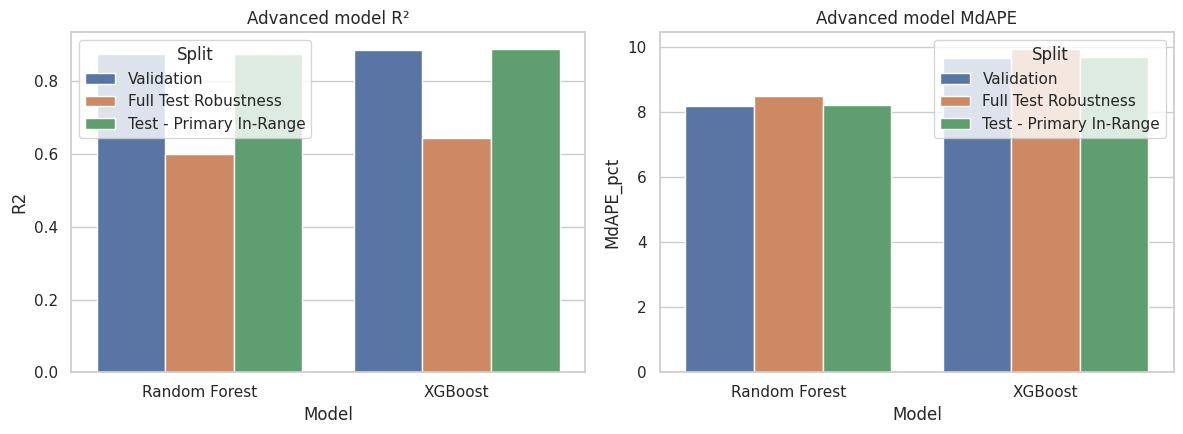

,Feature,Importance
247,categorical__CountyOrParish_San Bernardino,0.083535
248,categorical__CountyOrParish_San Diego,0.070464
244,categorical__CountyOrParish_Riverside,0.062280
413,categorical__HighSchoolDistrict_Newport Mesa U...,0.033894
226,categorical__PostalCode_infrequent_sklearn,0.033192
254,categorical__CountyOrParish_Santa Clara,0.029513
303,categorical__MLSAreaMajor_699 - Not Defined,0.022250
242,categorical__CountyOrParish_Orange,0.021378
577,categorical__DistrictName_Vista Unified,0.021008
252,categorical__CountyOrParish_San Mateo,0.016643


In [13]:
full_comparison = pd.concat([
    validation_comparison.assign(Split='Validation'),
    test_comparison,
], ignore_index=True)

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.barplot(data=full_comparison, x='Model', y='R2', hue='Split', ax=axes[0])
axes[0].set_title('Advanced model R²')
sns.barplot(data=full_comparison, x='Model', y='MdAPE_pct', hue='Split', ax=axes[1])
axes[1].set_title('Advanced model MdAPE')
plt.tight_layout()
plt.show()

feature_names = xgb_model.named_steps['preprocessing'].get_feature_names_out()
importance = (
    pd.DataFrame({
        'Feature': feature_names,
        'Importance': xgb_model.named_steps['model'].feature_importances_,
    })
    .sort_values('Importance', ascending=False)
    .head(20)
)
display(importance)


## 13. Save reproducible advanced-model artifacts


In [14]:
ADVANCED_DIR = OUTPUT_DIR / 'advanced_models'
ADVANCED_DIR.mkdir(parents=True, exist_ok=True)

cv_results.to_csv(ADVANCED_DIR / 'xgboost_time_cv_results.csv', index=False)
full_comparison.to_csv(ADVANCED_DIR / 'advanced_model_metrics.csv', index=False)
population_summary.to_csv(ADVANCED_DIR / 'evaluation_population_summary.csv', index=False)
importance.to_csv(ADVANCED_DIR / 'xgboost_feature_importance.csv', index=False)
pd.DataFrame({
    'ActualClosePrice': y_test.to_numpy(),
    'SelectedModelPrediction': test_predictions[selected_model_name],
}).to_csv(ADVANCED_DIR / 'selected_model_test_predictions.csv', index=False)

joblib.dump(
    {
        'model_name': selected_model_name,
        'model': selected_model,
        'numeric_features': updated_numeric,
        'categorical_features': updated_categorical,
        'best_xgboost_params': search.best_params_,
        'selection_metric': 'validation MdAPE',
        'evaluation_bounds': {
            'closeprice_p005_train': float(price_low),
            'closeprice_p995_train': float(price_high),
            'price_per_sqft_p005_train': float(ppsf_low),
            'price_per_sqft_p995_train': float(ppsf_high),
        },
    },
    ADVANCED_DIR / 'selected_advanced_model.joblib',
)
print('Saved advanced-model outputs to:', ADVANCED_DIR)


Saved advanced-model outputs to: /content/drive/MyDrive/IDX Exchange/outputs/advanced_models


## Interpretation and limitations

- Time-aware cross-validation reduces optimistic tuning caused by mixing earlier and later transactions.
- Validation chooses between Random Forest and XGBoost; June test metrics are the final generalization check.
- The model with the highest R² may not have the lowest typical percentage error, so the deployment choice must follow the business objective.
- Feature importance reflects predictive use, not causality.
- School-district membership supplies geographic context only and does not represent school quality.
